# 📊 SatEnergy — Notebook 02: Análise Exploratória de Dados (EDA)

**Objetivo:** Explorar, visualizar e entender os dados coletados no Notebook 01, identificando padrões, correlações e insights que alimentarão os modelos preditivos.

| Seção | Análise |
|-------|---------|
| 1 | Distribuição do fator de capacidade solar e eólica |
| 2 | Sazonalidade e padrões temporais |
| 3 | Correlação entre variáveis |
| 4 | Distribuição geográfica dos focos de calor |
| 5 | Análise de risco por região e tensão |

## 0. Imports e Configuração

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import geopandas as gpd
import requests
import json
import zipfile
import re
import warnings

from io import StringIO
from datetime import datetime
from shapely.geometry import Point
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(f"✅ Bibliotecas carregadas | Pandas {pd.__version__} | NumPy {np.__version__}")

✅ Bibliotecas carregadas | Pandas 3.0.3 | NumPy 2.4.6


## 1. Carregando os Dados

In [2]:
import glob

# ONS — Fator de capacidade
arquivos = glob.glob("../data/raw/FATOR*.csv")
df_ons = pd.read_csv(arquivos[0], sep=";", encoding="utf-8")
df_ons["din_instante"] = pd.to_datetime(df_ons["din_instante"])
df_ons["mes"] = df_ons["din_instante"].dt.month
df_ons["hora"] = df_ons["din_instante"].dt.hour

df_solar  = df_ons[df_ons["nom_tipousina"] == "Solar"].copy()
df_eolica = df_ons[df_ons["nom_tipousina"] == "Eólica"].copy()

print(f"✅ ONS: {len(df_ons):,} registros | {df_solar['nom_usina_conjunto'].nunique()} usinas solares | {df_eolica['nom_usina_conjunto'].nunique()} usinas eólicas")

✅ ONS: 166,320 registros | 78 usinas solares | 153 usinas eólicas


## 2. Distribuição do Fator de Capacidade

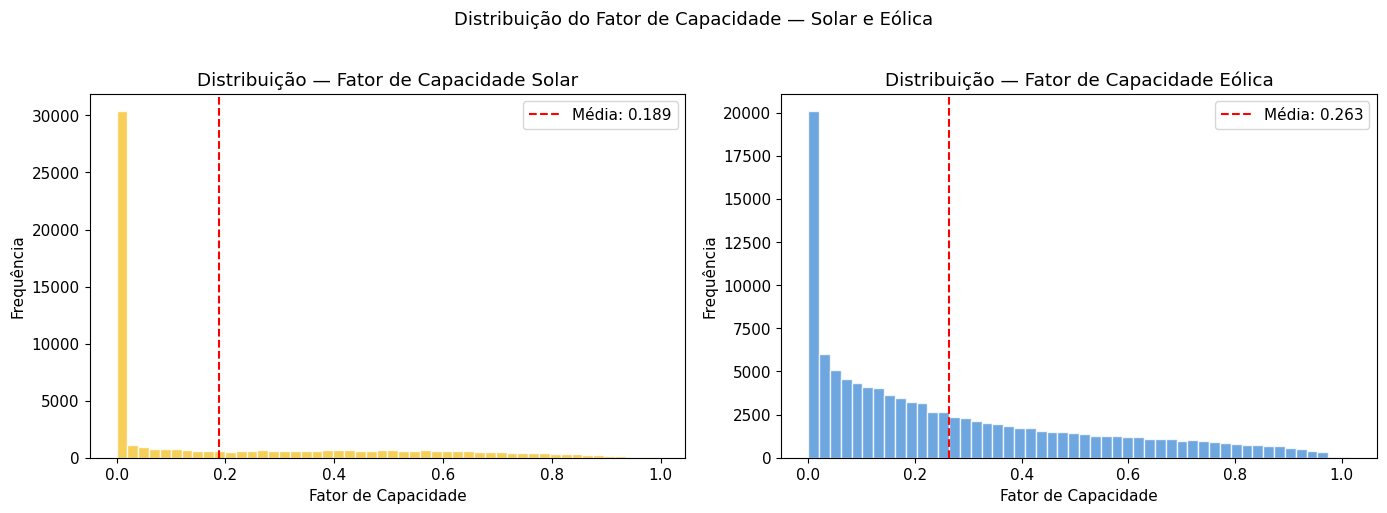

✅ Gráfico salvo


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar
axes[0].hist(df_solar["val_fatorcapacidade"].dropna(), bins=50, color="#f4c430", edgecolor="white", alpha=0.8)
axes[0].axvline(df_solar["val_fatorcapacidade"].mean(), color="red", linestyle="--", label=f"Média: {df_solar['val_fatorcapacidade'].mean():.3f}")
axes[0].set_title("Distribuição — Fator de Capacidade Solar")
axes[0].set_xlabel("Fator de Capacidade")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Eólica
axes[1].hist(df_eolica["val_fatorcapacidade"].dropna(), bins=50, color="#4a90d9", edgecolor="white", alpha=0.8)
axes[1].axvline(df_eolica["val_fatorcapacidade"].mean(), color="red", linestyle="--", label=f"Média: {df_eolica['val_fatorcapacidade'].mean():.3f}")
axes[1].set_title("Distribuição — Fator de Capacidade Eólica")
axes[1].set_xlabel("Fator de Capacidade")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.suptitle("Distribuição do Fator de Capacidade — Solar e Eólica", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_distribuicao_fc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 3. Sazonalidade — Fator de Capacidade por Hora do Dia

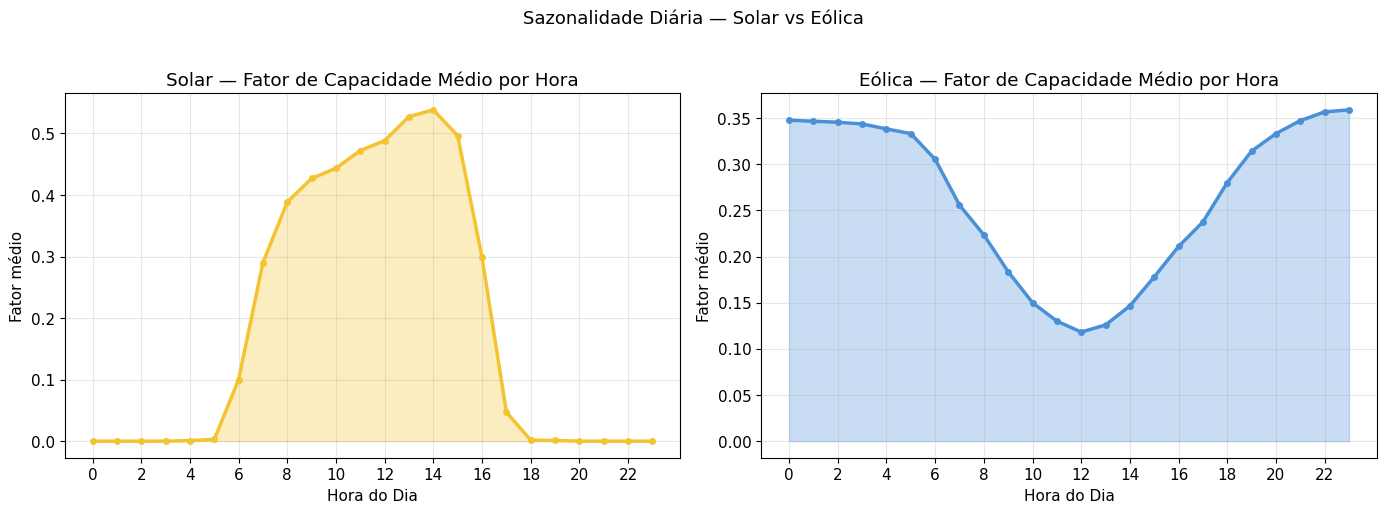

✅ Gráfico salvo


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar por hora
solar_hora = df_solar.groupby("hora")["val_fatorcapacidade"].mean()
axes[0].plot(solar_hora.index, solar_hora.values, color="#f4c430", linewidth=2.5, marker="o", markersize=4)
axes[0].fill_between(solar_hora.index, solar_hora.values, alpha=0.3, color="#f4c430")
axes[0].set_title("Solar — Fator de Capacidade Médio por Hora")
axes[0].set_xlabel("Hora do Dia")
axes[0].set_ylabel("Fator médio")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)

# Eólica por hora
eolica_hora = df_eolica.groupby("hora")["val_fatorcapacidade"].mean()
axes[1].plot(eolica_hora.index, eolica_hora.values, color="#4a90d9", linewidth=2.5, marker="o", markersize=4)
axes[1].fill_between(eolica_hora.index, eolica_hora.values, alpha=0.3, color="#4a90d9")
axes[1].set_title("Eólica — Fator de Capacidade Médio por Hora")
axes[1].set_xlabel("Hora do Dia")
axes[1].set_ylabel("Fator médio")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)

plt.suptitle("Sazonalidade Diária — Solar vs Eólica", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_sazonalidade_hora.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 4. Fator de Capacidade por Subsistema e Mês

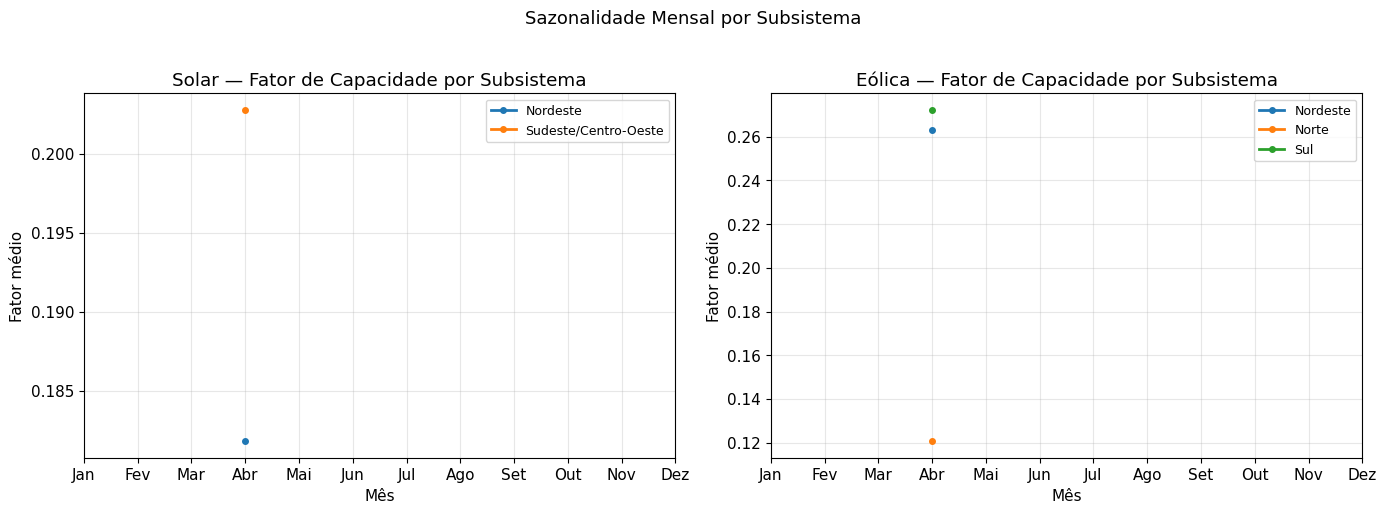

✅ Gráfico salvo


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar por subsistema e mês
solar_pivot = df_solar.groupby(["mes", "nom_subsistema"])["val_fatorcapacidade"].mean().unstack()
solar_pivot.plot(ax=axes[0], linewidth=2, marker="o", markersize=4)
axes[0].set_title("Solar — Fator de Capacidade por Subsistema")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Fator médio")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Eólica por subsistema e mês
eolica_pivot = df_eolica.groupby(["mes", "nom_subsistema"])["val_fatorcapacidade"].mean().unstack()
eolica_pivot.plot(ax=axes[1], linewidth=2, marker="o", markersize=4)
axes[1].set_title("Eólica — Fator de Capacidade por Subsistema")
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Fator médio")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Sazonalidade Mensal por Subsistema", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_sazonalidade_mes.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 5. Top 10 Usinas — Melhor Desempenho

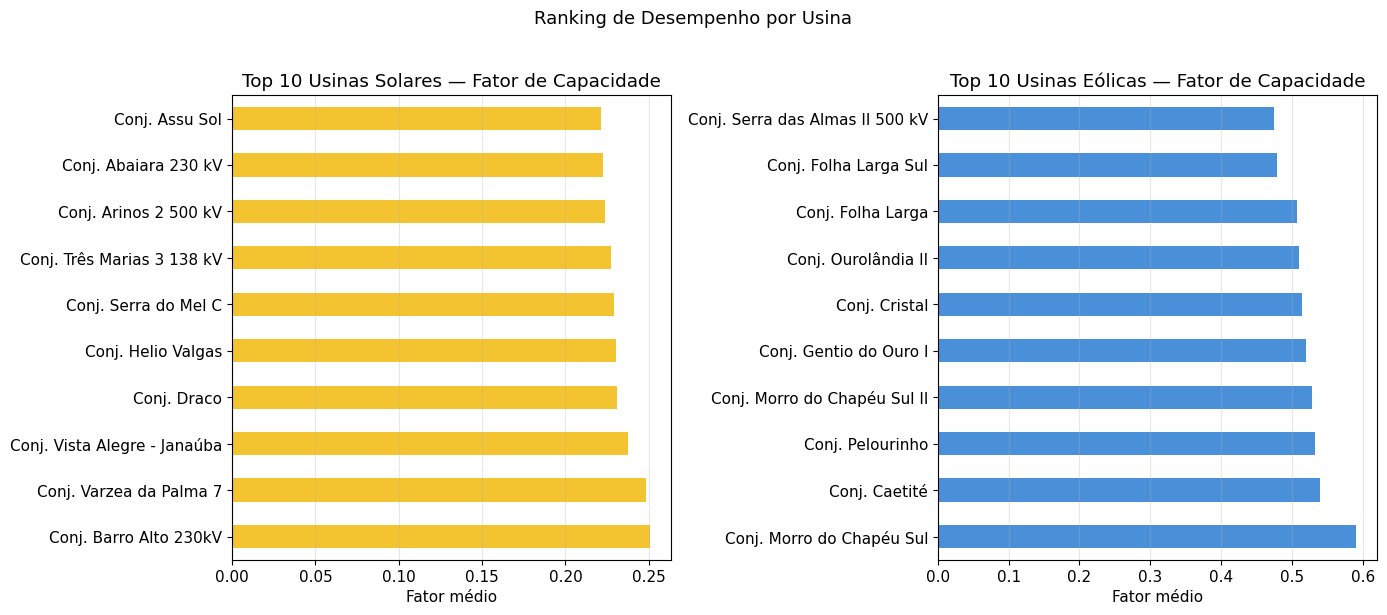

✅ Gráfico salvo


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 solar
top_solar = df_solar.groupby("nom_usina_conjunto")["val_fatorcapacidade"].mean().nlargest(10)
top_solar.plot(kind="barh", ax=axes[0], color="#f4c430")
axes[0].set_title("Top 10 Usinas Solares — Fator de Capacidade")
axes[0].set_xlabel("Fator médio")
axes[0].set_ylabel("")
axes[0].grid(True, alpha=0.3, axis="x")

# Top 10 eólica
top_eolica = df_eolica.groupby("nom_usina_conjunto")["val_fatorcapacidade"].mean().nlargest(10)
top_eolica.plot(kind="barh", ax=axes[1], color="#4a90d9")
axes[1].set_title("Top 10 Usinas Eólicas — Fator de Capacidade")
axes[1].set_xlabel("Fator médio")
axes[1].set_ylabel("")
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle("Ranking de Desempenho por Usina", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_top10_usinas.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 6. Correlação entre Geração Programada e Verificada

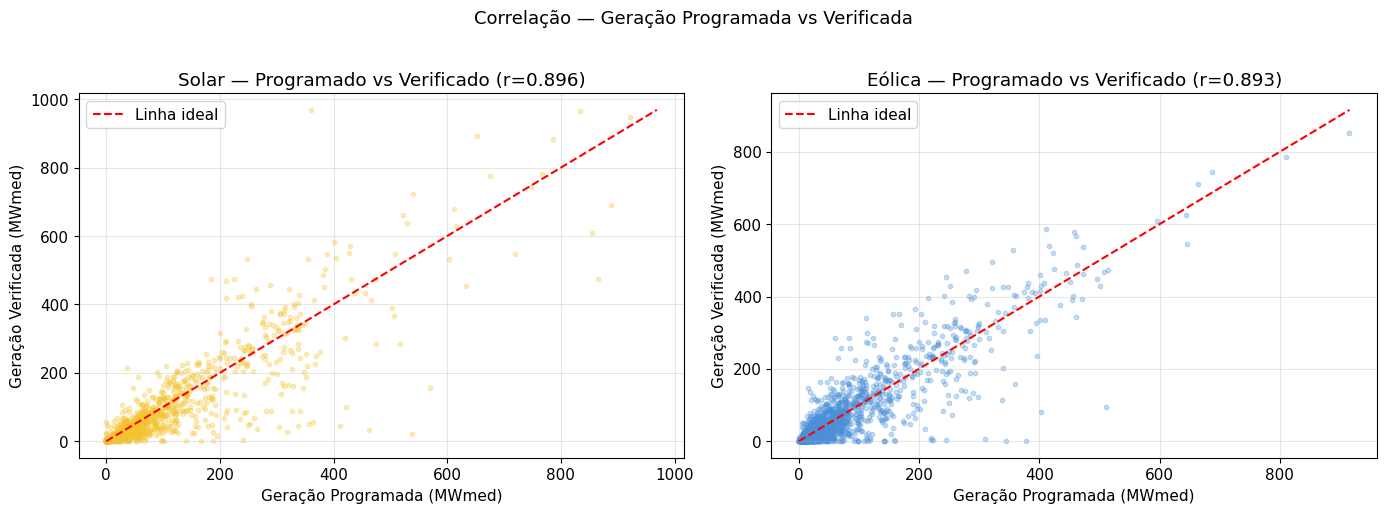

✅ Gráfico salvo


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amostra para não sobrecarregar o gráfico
sample_solar  = df_solar.dropna(subset=["val_geracaoprogramada", "val_geracaoverificada"]).sample(min(2000, len(df_solar)), random_state=42)
sample_eolica = df_eolica.dropna(subset=["val_geracaoprogramada", "val_geracaoverificada"]).sample(min(2000, len(df_eolica)), random_state=42)

# Solar
axes[0].scatter(sample_solar["val_geracaoprogramada"], sample_solar["val_geracaoverificada"],
                alpha=0.3, color="#f4c430", s=10)
max_val = max(sample_solar["val_geracaoprogramada"].max(), sample_solar["val_geracaoverificada"].max())
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Linha ideal")
corr_s = sample_solar[["val_geracaoprogramada", "val_geracaoverificada"]].corr().iloc[0,1]
axes[0].set_title(f"Solar — Programado vs Verificado (r={corr_s:.3f})")
axes[0].set_xlabel("Geração Programada (MWmed)")
axes[0].set_ylabel("Geração Verificada (MWmed)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Eólica
axes[1].scatter(sample_eolica["val_geracaoprogramada"], sample_eolica["val_geracaoverificada"],
                alpha=0.3, color="#4a90d9", s=10)
max_val = max(sample_eolica["val_geracaoprogramada"].max(), sample_eolica["val_geracaoverificada"].max())
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Linha ideal")
corr_e = sample_eolica[["val_geracaoprogramada", "val_geracaoverificada"]].corr().iloc[0,1]
axes[1].set_title(f"Eólica — Programado vs Verificado (r={corr_e:.3f})")
axes[1].set_xlabel("Geração Programada (MWmed)")
axes[1].set_ylabel("Geração Verificada (MWmed)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Correlação — Geração Programada vs Verificada", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_correlacao_geracao.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 7. Análise de Risco — Focos de Calor vs Infraestrutura

Carregando os alertas gerados no Notebook 01.

In [8]:
# Carrega alertas salvos
df_alertas = pd.read_csv("../data/processed/alertas_risco.csv")
print(f"✅ {len(df_alertas)} alertas carregados")
print(f"\nDistribuição de risco:")
print(df_alertas["Risco"].value_counts())
print(f"\nDistância mínima: {df_alertas['Dist (km)'].min():.2f} km")
print(f"Distância máxima: {df_alertas['Dist (km)'].max():.2f} km")
print(f"Distância média:  {df_alertas['Dist (km)'].mean():.2f} km")

✅ 2 alertas carregados

Distribuição de risco:
Risco
🔴 CRÍTICO    1
🟢 BAIXO      1
Name: count, dtype: int64

Distância mínima: 0.32 km
Distância máxima: 110.49 km
Distância média:  55.40 km


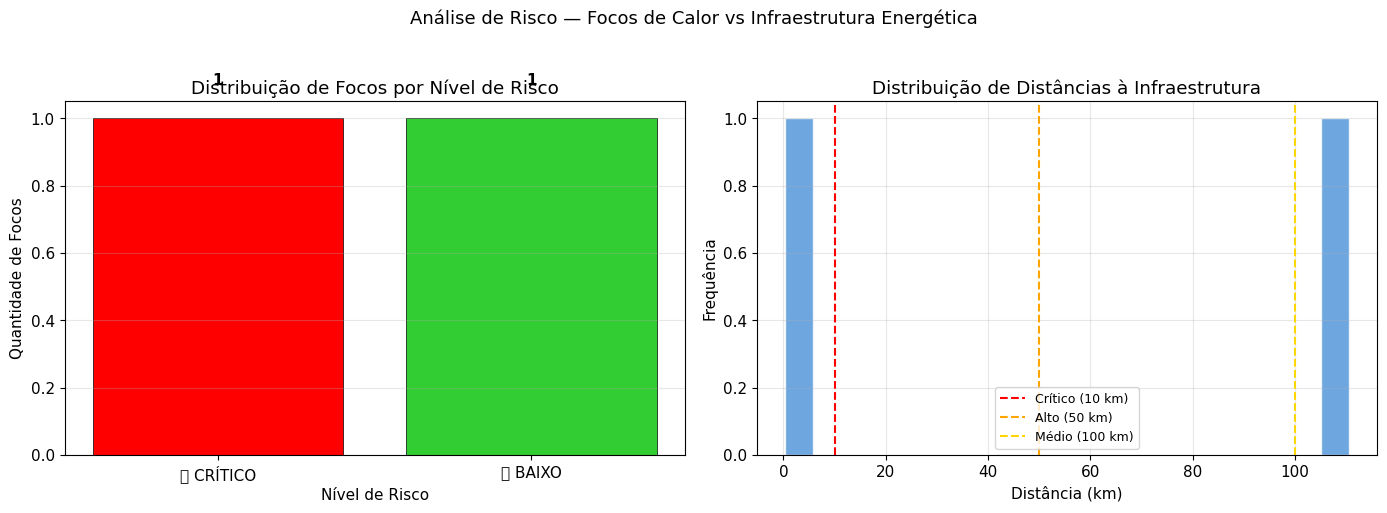

✅ Gráfico salvo


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de risco
cores = {"🔴 CRÍTICO": "red", "🟠 ALTO": "orange", "🟡 MÉDIO": "yellow", "🟢 BAIXO": "limegreen"}
contagem = df_alertas["Risco"].value_counts()
bars = axes[0].bar(contagem.index, contagem.values,
                   color=[cores.get(r, "gray") for r in contagem.index],
                   edgecolor="black", linewidth=0.5)
axes[0].set_title("Distribuição de Focos por Nível de Risco")
axes[0].set_xlabel("Nível de Risco")
axes[0].set_ylabel("Quantidade de Focos")
axes[0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, contagem.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', fontsize=11, fontweight='bold')

# Histograma de distâncias
axes[1].hist(df_alertas["Dist (km)"], bins=20, color="#4a90d9", edgecolor="white", alpha=0.8)
axes[1].axvline(10,  color="red",    linestyle="--", linewidth=1.5, label="Crítico (10 km)")
axes[1].axvline(50,  color="orange", linestyle="--", linewidth=1.5, label="Alto (50 km)")
axes[1].axvline(100, color="gold",   linestyle="--", linewidth=1.5, label="Médio (100 km)")
axes[1].set_title("Distribuição de Distâncias à Infraestrutura")
axes[1].set_xlabel("Distância (km)")
axes[1].set_ylabel("Frequência")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Análise de Risco — Focos de Calor vs Infraestrutura Energética", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/eda_analise_risco.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo")

## 8. Resumo Estatístico — Insights para os Modelos

In [10]:
print("=" * 70)
print("📊 RESUMO EDA — SATENERGY")
print("=" * 70)

print("\n🌞 GERAÇÃO SOLAR:")
print(f"   Fator médio:          {df_solar['val_fatorcapacidade'].mean():.3f}")
print(f"   Fator máximo:         {df_solar['val_fatorcapacidade'].max():.3f}")
print(f"   Melhor subsistema:    {df_solar.groupby('nom_subsistema')['val_fatorcapacidade'].mean().idxmax()}")
print(f"   Pico de geração:      {int(solar_hora.idxmax())}h")

print("\n💨 GERAÇÃO EÓLICA:")
print(f"   Fator médio:          {df_eolica['val_fatorcapacidade'].mean():.3f}")
print(f"   Fator máximo:         {df_eolica['val_fatorcapacidade'].max():.3f}")
print(f"   Melhor subsistema:    {df_eolica.groupby('nom_subsistema')['val_fatorcapacidade'].mean().idxmax()}")

print("\n🔥 RISCO CLIMÁTICO:")
print(f"   Total de focos:       {len(df_alertas)}")
print(f"   Focos críticos:       {len(df_alertas[df_alertas['Risco'] == '🔴 CRÍTICO'])}")
print(f"   Menor distância:      {df_alertas['Dist (km)'].min():.2f} km")
if len(df_alertas) > 0:
    linha_critica = df_alertas.loc[df_alertas['Dist (km)'].idxmin()]
    print(f"   Linha mais ameaçada:  {linha_critica['Linha']}")
    print(f"   Tensão:               {linha_critica['Tensão (kV)']} kV")

print("\n✅ EDA concluída — dados prontos para modelagem!")
print("=" * 70)

📊 RESUMO EDA — SATENERGY

🌞 GERAÇÃO SOLAR:
   Fator médio:          0.189
   Fator máximo:         0.996
   Melhor subsistema:    Sudeste/Centro-Oeste
   Pico de geração:      14h

💨 GERAÇÃO EÓLICA:
   Fator médio:          0.263
   Fator máximo:         1.015
   Melhor subsistema:    Sul

🔥 RISCO CLIMÁTICO:
   Total de focos:       2
   Focos críticos:       1
   Menor distância:      0.32 km
   Linha mais ameaçada:  LT 800 kV Graça Aranha – Silvânia
   Tensão:               800.0 kV

✅ EDA concluída — dados prontos para modelagem!
